<a href="https://colab.research.google.com/github/Srushti070/YuvaIntern-Logistics-Data-Analyst/blob/main/Week-2/Task_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler, StandardScaler

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
orders = pd.read_csv("olist_orders_dataset.csv")
items = pd.read_csv("olist_order_items_dataset.csv")

print("Orders shape:", orders.shape)
print("Order Items shape:", items.shape)

Orders shape: (99441, 8)
Order Items shape: (112650, 7)


In [3]:
print("ORDERS DATA")
display(orders.head())

print("\nORDER ITEMS DATA")
display(items.head())

ORDERS DATA


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00



ORDER ITEMS DATA


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [4]:
print("Orders Data Types:")
print(orders.dtypes)

print("\nOrder Items Data Types:")
print(items.dtypes)

Orders Data Types:
order_id                         object
customer_id                      object
order_status                     object
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object
dtype: object

Order Items Data Types:
order_id                object
order_item_id            int64
product_id              object
seller_id               object
shipping_limit_date     object
price                  float64
freight_value          float64
dtype: object


In [5]:
print("Missing values in Orders:")
print(orders.isnull().sum())

print("\nMissing values in Order Items:")
print(items.isnull().sum())

Missing values in Orders:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

Missing values in Order Items:
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64


In [6]:
print("Duplicate rows in Orders:", orders.duplicated().sum())
print("Duplicate rows in Order Items:", items.duplicated().sum())

Duplicate rows in Orders: 0
Duplicate rows in Order Items: 0


In [7]:
orders = orders.drop_duplicates()
items = items.drop_duplicates()

print("Orders shape after removing duplicates:", orders.shape)
print("Order Items shape after removing duplicates:", items.shape)

Orders shape after removing duplicates: (99441, 8)
Order Items shape after removing duplicates: (112650, 7)


In [8]:
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_columns:
    orders[col] = pd.to_datetime(orders[col], errors="coerce")

print(orders[date_columns].dtypes)

order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object


In [9]:
orders["delivery_days"] = (
    orders["order_delivered_customer_date"]
    - orders["order_purchase_timestamp"]
).dt.total_seconds() / 86400

orders["delay_days"] = (
    orders["order_delivered_customer_date"]
    - orders["order_estimated_delivery_date"]
).dt.total_seconds() / 86400

orders["late_flag"] = (orders["delay_days"] > 0).astype(int)

print(orders[
    ["order_id", "delivery_days", "delay_days", "late_flag"]
].head())

                           order_id  delivery_days  delay_days  late_flag
0  e481f51cbdc54678b7cc49136f2d6af7       8.436574   -7.107488          0
1  53cdb2fc8bc7dce0b6741e2150273451      13.782037   -5.355729          0
2  47770eb9100c2d0c44946d9cf07ec65d       9.394213  -17.245498          0
3  949d5b44dbf5de918fe9c16f97b45f8a      13.208750  -12.980069          0
4  ad21c59c0840e6cb83a9ceb5573f8159       2.873877   -9.238171          0


In [10]:
print("Negative delivery days:",
      (orders["delivery_days"] < 0).sum())

print("Negative freight values:",
      (items["freight_value"] < 0).sum())

print("Negative product prices:",
      (items["price"] < 0).sum())

Negative delivery days: 0
Negative freight values: 0
Negative product prices: 0


In [11]:
Q1 = orders["delivery_days"].quantile(0.25)
Q3 = orders["delivery_days"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = orders[
    (orders["delivery_days"] < lower_bound) |
    (orders["delivery_days"] > upper_bound)
]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)
print("Number of delivery-time outliers:", len(outliers))

Q1: 6.766403356481481
Q3: 15.720326967592593
IQR: 8.953923611111112
Lower Bound: -6.664482060185186
Upper Bound: 29.15121238425926
Number of delivery-time outliers: 4899


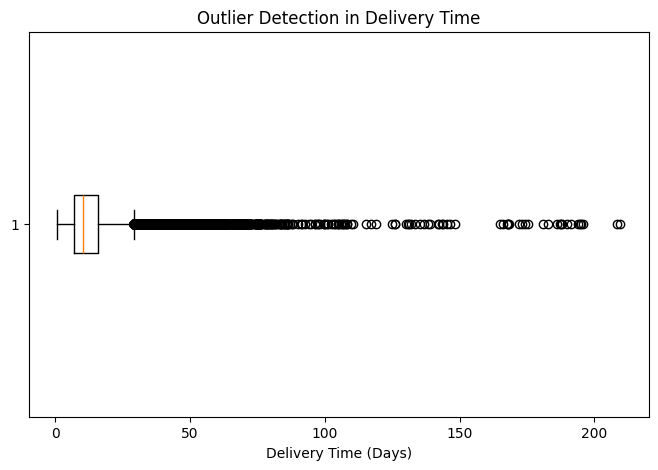

In [12]:
plt.figure(figsize=(8, 5))

plt.boxplot(
    orders["delivery_days"].dropna(),
    vert=False
)

plt.xlabel("Delivery Time (Days)")
plt.title("Outlier Detection in Delivery Time")

plt.show()

In [13]:
orders["delivery_days_capped"] = orders["delivery_days"].clip(
    lower=lower_bound,
    upper=upper_bound
)

print("Original maximum delivery time:",
      orders["delivery_days"].max())

print("Capped maximum delivery time:",
      orders["delivery_days_capped"].max())

Original maximum delivery time: 209.6286111111111
Capped maximum delivery time: 29.15121238425926


In [14]:
clean_orders = orders.dropna(
    subset=[
        "order_purchase_timestamp",
        "order_delivered_customer_date",
        "order_estimated_delivery_date"
    ]
).copy()

print("Original orders:", len(orders))
print("Clean orders:", len(clean_orders))
print("Rows removed:", len(orders) - len(clean_orders))

Original orders: 99441
Clean orders: 96476
Rows removed: 2965


In [15]:
scaler = MinMaxScaler()

clean_orders["delivery_days_normalized"] = scaler.fit_transform(
    clean_orders[["delivery_days_capped"]]
)

print(
    clean_orders[
        ["delivery_days_capped", "delivery_days_normalized"]
    ].head()
)

   delivery_days_capped  delivery_days_normalized
0              8.436574                  0.276162
1             13.782037                  0.462950
2              9.394213                  0.309625
3             13.208750                  0.442918
4              2.873877                  0.081783


In [16]:
standard_scaler = StandardScaler()

clean_orders["delivery_days_standardized"] = standard_scaler.fit_transform(
    clean_orders[["delivery_days_capped"]]
)

print(
    clean_orders[
        ["delivery_days_capped", "delivery_days_standardized"]
    ].head()
)

   delivery_days_capped  delivery_days_standardized
0              8.436574                   -0.494594
1             13.782037                    0.254063
2              9.394213                   -0.360473
3             13.208750                    0.173771
4              2.873877                   -1.273676


In [17]:
print("BEFORE PREPROCESSING")
print("Rows:", len(orders))
print("Missing delivery dates:",
      orders["order_delivered_customer_date"].isnull().sum())
print("Maximum delivery days:",
      orders["delivery_days"].max())

print("\nAFTER PREPROCESSING")
print("Rows:", len(clean_orders))
print("Missing delivery dates:",
      clean_orders["order_delivered_customer_date"].isnull().sum())
print("Maximum capped delivery days:",
      clean_orders["delivery_days_capped"].max())

BEFORE PREPROCESSING
Rows: 99441
Missing delivery dates: 2965
Maximum delivery days: 209.6286111111111

AFTER PREPROCESSING
Rows: 96476
Missing delivery dates: 0
Maximum capped delivery days: 29.15121238425926


In [18]:
print("Final dataset shape:", clean_orders.shape)

print("\nRemaining missing values:")
print(clean_orders.isnull().sum())

print("\nFinal data types:")
print(clean_orders.dtypes)

Final dataset shape: (96476, 14)

Remaining missing values:
order_id                          0
customer_id                       0
order_status                      0
order_purchase_timestamp          0
order_approved_at                14
order_delivered_carrier_date      1
order_delivered_customer_date     0
order_estimated_delivery_date     0
delivery_days                     0
delay_days                        0
late_flag                         0
delivery_days_capped              0
delivery_days_normalized          0
delivery_days_standardized        0
dtype: int64

Final data types:
order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
delivery_days       